In [1]:
import numpy as np
np.random.seed(42)


In [2]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()


In [3]:
import os
print(os.path.expanduser("~/.keras/datasets"))


C:\Users\Akshatha/.keras/datasets


In [4]:
X_train = X_train.reshape(-1, 784) / 255.0
X_test  = X_test.reshape(-1, 784) / 255.0


In [5]:
#Prepare labels (One-Hot Encoding)
import numpy as np

def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train_oh = one_hot(y_train)
y_test_oh  = one_hot(y_test)


In [6]:
#Initialize parameters
np.random.seed(42)

input_size = 784
hidden_size = 128
output_size = 10

W1 = 0.01 * np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))

W2 = 0.01 * np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))


In [7]:
#Activation functions
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


In [8]:
#Forward pass
def forward(X):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    y_hat = softmax(z2)
    return z1, a1, y_hat


In [9]:
#Loss function (Cross-Entropy)
def cross_entropy(y_true, y_pred):
    eps = 1e-9
    return -np.mean(np.sum(y_true * np.log(y_pred + eps), axis=1))


In [10]:
#Backpropagation
def backward(X, y_true, z1, a1, y_pred):
    global W1, b1, W2, b2
    
    m = X.shape[0]

    dz2 = y_pred - y_true
    dW2 = (a1.T @ dz2) / m
    db2 = np.sum(dz2, axis=0, keepdims=True) / m

    da1 = dz2 @ W2.T
    dz1 = da1 * relu_derivative(z1)
    dW1 = (X.T @ dz1) / m
    db1 = np.sum(dz1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2


In [11]:
#SGD update
def update(dW1, db1, dW2, db2, lr):
    global W1, b1, W2, b2
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2


In [13]:
# 8. Training loop
# --------------------------------------------------
epochs = 20
batch_size = 64
lr = 0.01

losses = []
accuracies = []

for epoch in range(epochs):
    idx = np.random.permutation(len(X_train))

    X_shuffled = X_train[idx]
    y_shuffled_oh = y_train_oh[idx]
    y_shuffled = y_train[idx]

    for i in range(0, len(X_shuffled), batch_size):
        Xb = X_shuffled[i:i+batch_size]
        yb = y_shuffled_oh[i:i+batch_size]

        z1, a1, y_pred = forward(Xb)
        loss = cross_entropy(yb, y_pred)

        dW1, db1, dW2, db2 = backward(Xb, yb, z1, a1, y_pred)
        update(dW1, db1, dW2, db2, lr)

    _, _, y_test_pred = forward(X_test)
    test_acc = np.mean(np.argmax(y_test_pred, axis=1) == y_test)

    losses.append(loss)
    accuracies.append(test_acc)

    print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Accuracy: {test_acc:.4f}")



Epoch 1, Loss: 0.1318, Accuracy: 0.9437
Epoch 2, Loss: 0.0486, Accuracy: 0.9453
Epoch 3, Loss: 0.1244, Accuracy: 0.9458
Epoch 4, Loss: 0.1325, Accuracy: 0.9465
Epoch 5, Loss: 0.2313, Accuracy: 0.9477
Epoch 6, Loss: 0.1381, Accuracy: 0.9494
Epoch 7, Loss: 0.2517, Accuracy: 0.9502
Epoch 8, Loss: 0.1429, Accuracy: 0.9510
Epoch 9, Loss: 0.2294, Accuracy: 0.9519
Epoch 10, Loss: 0.0538, Accuracy: 0.9533
Epoch 11, Loss: 0.0375, Accuracy: 0.9533
Epoch 12, Loss: 0.1685, Accuracy: 0.9546
Epoch 13, Loss: 0.2938, Accuracy: 0.9557
Epoch 14, Loss: 0.2117, Accuracy: 0.9562
Epoch 15, Loss: 0.0958, Accuracy: 0.9577
Epoch 16, Loss: 0.1788, Accuracy: 0.9581
Epoch 17, Loss: 0.1441, Accuracy: 0.9589
Epoch 18, Loss: 0.0543, Accuracy: 0.9591
Epoch 19, Loss: 0.1729, Accuracy: 0.9604
Epoch 20, Loss: 0.1515, Accuracy: 0.9614


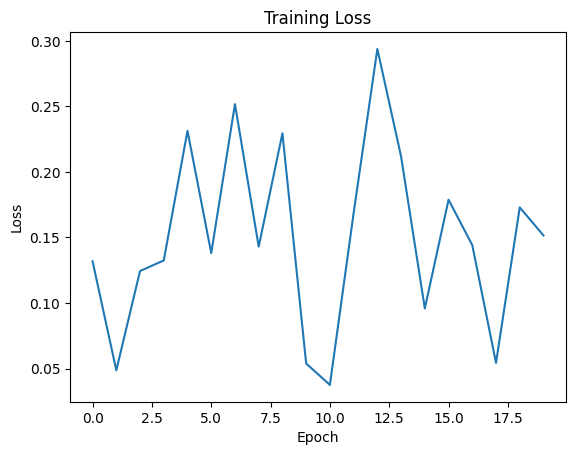

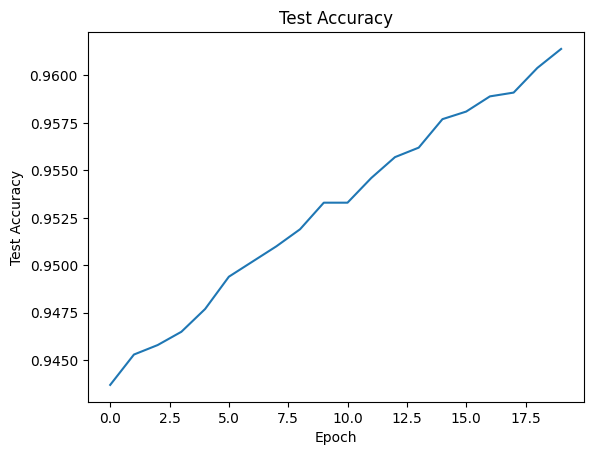

In [14]:
# 9. Plot results
# --------------------------------------------------
import matplotlib.pyplot as plt

plt.figure()
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

plt.figure()
plt.plot(accuracies)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy")
plt.show()


In [15]:
#autoencoder code
np.random.seed(42)

input_size = 784
h1 = 128
latent = 32

W1 = np.random.randn(input_size, h1) * 0.01
b1 = np.zeros((1, h1))

W2 = np.random.randn(h1, latent) * 0.01
b2 = np.zeros((1, latent))

W3 = np.random.randn(latent, h1) * 0.01
b3 = np.zeros((1, h1))

W4 = np.random.randn(h1, input_size) * 0.01
b4 = np.zeros((1, input_size))


In [16]:
#Activation functions
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [17]:
#Forward pass
def ae_forward(X):
    z1 = X @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    latent_vec = relu(z2)

    z3 = latent_vec @ W3 + b3
    a3 = relu(z3)

    z4 = a3 @ W4 + b4
    X_hat = sigmoid(z4)

    return z1, z2, z3, latent_vec, X_hat


In [18]:
#Loss (MSE + sparsity)
def ae_loss(X, X_hat, latent_vec, l1_lambda=1e-4):
    mse = np.mean((X - X_hat) ** 2)
    l1 = l1_lambda * np.mean(np.abs(latent_vec))
    return mse + l1


In [19]:
#Backpropagation
def ae_backward(X, z1, z2, z3, latent_vec, X_hat):
    global W1, b1, W2, b2, W3, b3, W4, b4

    m = X.shape[0]

    dX_hat = (X_hat - X) / m
    dz4 = dX_hat * X_hat * (1 - X_hat)

    dW4 = z3.T @ dz4
    db4 = np.sum(dz4, axis=0, keepdims=True)

    da3 = dz4 @ W4.T
    dz3 = da3 * relu_derivative(z3)

    dW3 = latent_vec.T @ dz3
    db3 = np.sum(dz3, axis=0, keepdims=True)

    da2 = dz3 @ W3.T
    dz2 = da2 * relu_derivative(z2)

    dW2 = z1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    da1 = dz2 @ W2.T
    dz1 = da1 * relu_derivative(z1)

    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3, dW4, db4


In [22]:
#Training loop
epochs = 20
lr = 0.01
batch_size = 128

ae_losses = []

for epoch in range(epochs):
    idx = np.random.permutation(len(X_train))
    X_shuffled = X_train[idx]

    for i in range(0, len(X_shuffled), batch_size):
        Xb = X_shuffled[i:i+batch_size]

        z1, z2, z3, latent_vec, X_hat = ae_forward(Xb)
        loss = ae_loss(Xb, X_hat, latent_vec)

        grads = ae_backward(Xb, z1, z2, z3, latent_vec, X_hat)

        for param, grad in zip(
            [W1,b1,W2,b2,W3,b3,W4,b4], grads
        ):
            param -= lr * grad

    ae_losses.append(loss)
    print(f"Epoch {epoch+1}, AE Loss: {loss:.4f}")


Epoch 1, AE Loss: 0.0354
Epoch 2, AE Loss: 0.0357
Epoch 3, AE Loss: 0.0359
Epoch 4, AE Loss: 0.0342
Epoch 5, AE Loss: 0.0334
Epoch 6, AE Loss: 0.0348
Epoch 7, AE Loss: 0.0325
Epoch 8, AE Loss: 0.0331
Epoch 9, AE Loss: 0.0313
Epoch 10, AE Loss: 0.0319
Epoch 11, AE Loss: 0.0304
Epoch 12, AE Loss: 0.0291
Epoch 13, AE Loss: 0.0310
Epoch 14, AE Loss: 0.0293
Epoch 15, AE Loss: 0.0324
Epoch 16, AE Loss: 0.0287
Epoch 17, AE Loss: 0.0261
Epoch 18, AE Loss: 0.0288
Epoch 19, AE Loss: 0.0281
Epoch 20, AE Loss: 0.0274


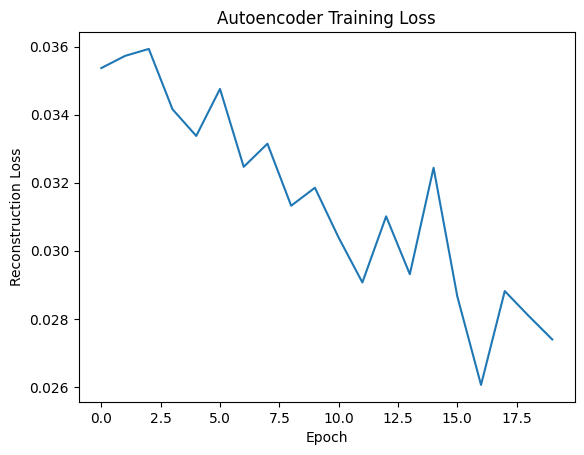

In [26]:
#autoencoder traning plot
plt.plot(ae_losses)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Autoencoder Training Loss")
plt.show()


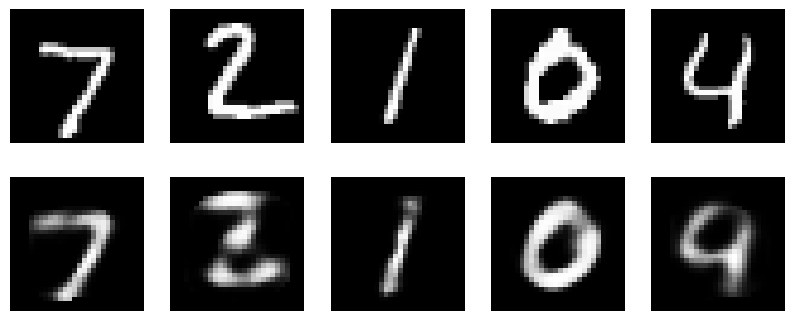

In [28]:
#reconstruction of normal samples
n = 5
samples = X_test[:n]
_, _, _, _, recon = ae_forward(samples)

plt.figure(figsize=(10,4))
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(samples[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2, n, i+1+n)
    plt.imshow(recon[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()


In [29]:
#outlier detection(Reconstruction error)
recon_all = ae_forward(X_test)[-1]
errors = np.mean((X_test - recon_all)**2, axis=1)

threshold = np.mean(errors) + 2*np.std(errors)
outliers = np.where(errors > threshold)[0]

print("Number of outliers detected:", len(outliers))


Number of outliers detected: 316


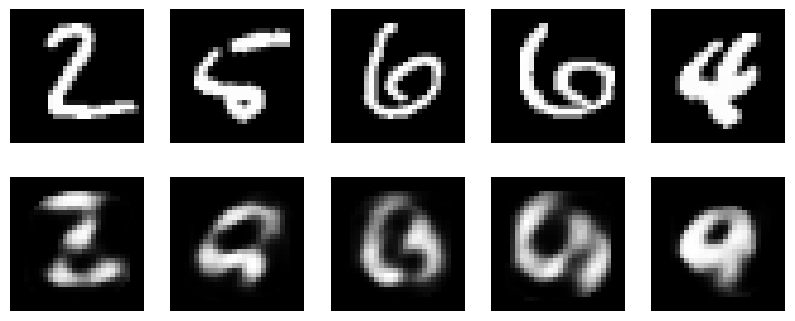

In [30]:
#outlier detection reconstruction
n = 5
plt.figure(figsize=(10,4))

for i, idx in enumerate(outliers[:n]):
    plt.subplot(2, n, i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2, n, i+1+n)
    plt.imshow(recon_all[idx].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()


NameError: name 'W' is not defined

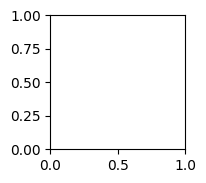

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
for i in range(16):   # 16 filters
    plt.subplot(4,4,i+1)
    plt.imshow(W[:, i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.suptitle("RBM Learned Filters")
plt.show()
